# Convolution Tutorial Series — Part 3: Stride

In [1]:
from IPython.display import Video

video_path = '/kaggle/input/datasets/massimilianoghiotto/neurogolf-convseries-part3-supportvideo/ConvTask149.mp4'

Video(video_path, width=750, height=450, embed=True)

**Goal:** Understand the **stride** attribute in the convolution. This is the third episode in our series covering the ONNX Conv function. We will explain these concepts simply using ARC tasks as examples. The previous episodes covered [Kernel Size & Bias](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-1) and [Padding](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-2).

**Task (ARC 149):**
1. **Grid Analysis:** The input is an 11x11 grid divided by gray (8) lines into a 3x3 arrangement of 3x3 blocks.
2. **The Rule:** For each 3x3 block, count the number of pink (6) pixels.
3. **The Output:** If a block contains 2 or more pink pixels, the corresponding output pixel is blue (1). Otherwise, it is black (0).

**Our approach:** Use a single Conv layer with **stride 4** to jump directly from one 3x3 block to the next, skipping the separator lines.

**Score formula:** `Points = max(1.0, 25.0 - log(Mem_bytes + Params))`

**Our result:** Mem=340, Params=97, **18.920 points**

---

In [2]:
!pip install -q numpy==2.4.4 2>/dev/null
!pip install -q onnx==1.21.0 2>/dev/null
!pip install -q onnxruntime==1.24.4 2>/dev/null
!pip install -q onnx-tool==1.0.1 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 751.9 kB/s eta 0:00:00


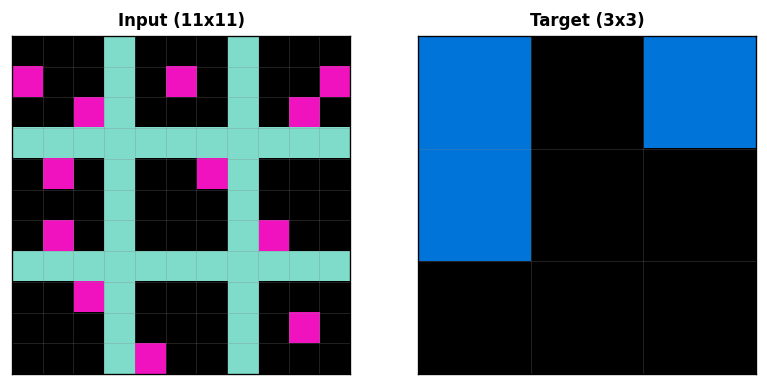

In [3]:
import json, warnings, os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import onnx
from onnx import helper, TensorProto, numpy_helper
import onnxruntime as ort

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

arc_colors = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00', 
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBCA', '#870C25'
]

def plot_arc_grid(grid, ax, title=''):
    H, W = len(grid), len(grid[0])
    img = np.zeros((H, W, 3), dtype=np.uint8)
    for r in range(H):
        for c in range(W):
            hex_c = arc_colors[grid[r][c]].lstrip('#')
            img[r,c] = [int(hex_c[i:i+2], 16) for i in (0, 2, 4)]
    ax.imshow(img, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10, fontweight='bold')
    for r in range(H+1): ax.axhline(r-0.5, color='gray', lw=0.5, alpha=0.3)
    for c in range(W+1): ax.axvline(c-0.5, color='gray', lw=0.5, alpha=0.3)

with open('/kaggle/input/competitions/neurogolf-2026/task149.json') as f:
    task = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_arc_grid(task['train'][0]['input'], axes[0], 'Input (11x11)')
plot_arc_grid(task['train'][0]['output'], axes[1], 'Target (3x3)')
plt.show()

# 1. What is the Stride?

Stride determines how many pixels the kernel moves after each computation. 
- **Stride 1 (Default):** The kernel moves 1 pixel at a time. Every possible window is checked.
- **Stride > 1:** The kernel "skips" pixels. This reduces the output resolution.

In Task 149, we have 3x3 blocks separated by a single line of gray pixels. 
- Block 1 starts at `(0,0)` and ends at `(2,2)`.
- The next block starts at `(0,4)`.
- To jump from the start of Block 1 to the start of Block 2, we need a **stride of 4**.
- The same regularity holds vertically.

By setting `strides=[4, 4]`, our 3x3 kernel will land exactly on the 9 relevant blocks and ignore the separator lines entirely!

# 2. The Model Design

### Step 1: Count Pink Pixels
We use a `Conv` layer with:
- **Kernel 3x3:** To match the block size.
- **Stride 4x4:** To jump over the gray lines.
- **Weights:** A single channel that sums pink (channel 6) pixels, so W is of dimensions [1, 10, 3, 3] with $W[0, 6, i, j] = 1.0$ for every i, j = 0, 1, 2 and zero otherwise.
- **Bias:** Set to `-1.5`. 
  - If count = 0 or 1, `count - 1.5` is **negative**.
  - If count $\ge$ 2, `count - 1.5` is **positive**.

This creates a 3x3 "score map" where positive values mean "At least 2 pink pixels found".

### Step 2: Channel Expansion and Padding
The competition expects a 10-channel 30x30 grid as input and output. We use four nodes to explain how this is assembled:
1. **Slice:**: Since the input is 30x30 we compute some extra zero values (see Section 3) that we eliminate with a single slice.
2. **Neg:** Creates the negative of our score map (for channel 0, the black background).
3. **Concat:** Combines the negative map (ch0) and the original map (ch1) into a 2-channel 3x3 tensor.
4. **Pad:** We pad the 2-channel 3x3 tensor on both the **channel dimension** (adding 8 empty channels to reach 10) and the **spatial dimensions** (adding 27 pixels to reach 30x30).

In [4]:
video_path = '/kaggle/input/datasets/massimilianoghiotto/neurogolf-convseries-part3-supportvideo/ConvTask149.mp4'

Video(video_path, width=750, height=450, embed=True)

In [5]:
def create_task149_model():
    # Setup Input/Output infos
    X = helper.make_tensor_value_info("input", TensorProto.FLOAT, [1, 10, 30, 30])
    Y = helper.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 30, 30])

    # Weights: Sum pink (ch6) over 3x3 windows
    w_conv = np.zeros((1, 10, 3, 3), dtype=np.float32)
    w_conv[0, 6, :, :] = 1.0
    b_conv = np.array([-1.5], dtype=np.float32)
    
    # Parameters for the slice
    starts = np.array([0, 0], dtype=np.int64)
    ends = np.array([3, 3], dtype=np.int64)
    axes = np.array([2, 3], dtype=np.int64)

    nodes = [
        # The Stride Magic: Jump every 4 pixels
        helper.make_node("Conv", ["input", "w_conv", "b_conv"], ["counts"],
                         kernel_shape=[3, 3], strides=[4, 4], pads=[0, 0, 0, 0]),

        # Slice to the active input
        helper.make_node("Slice", ["counts", "starts", "ends", "axes"], ["r3"]),
        
        # Logical Negation for Channel 0 (Background)
        helper.make_node("Neg", ["r3"], ["neg_counts"]),
        
        # Assemble active channels (0=Black, 1=Blue)
        helper.make_node("Concat", ["neg_counts", "r3"], ["r2"], axis=1),
        
        # Pad to 10 channels AND 30x30 spatial size in one go!
        # pads format: [n_begin, c_begin, h_begin, w_begin, n_end, c_end, h_end, w_end]
        helper.make_node("Pad", ["r2"], ["output"], mode="constant", value=0.0,
                         pads=[0, 0, 0, 0, 0, 8, 27, 27])
    ]

    graph = helper.make_graph(nodes, "stride_demo", [X], [Y], initializer=[
        numpy_helper.from_array(w_conv, name="w_conv"),
        numpy_helper.from_array(b_conv, name="b_conv"),
        numpy_helper.from_array(starts, name="starts"),
        numpy_helper.from_array(ends, name="ends"),
        numpy_helper.from_array(axes, name="axes"),
    ])
    
    model = helper.make_model(graph, opset_imports=[helper.make_operatorsetid("", 10)])
    return model

model = create_task149_model()
onnx.save(model, "stride_tutorial.onnx")

# 3. The Output Shape Formula

When using stride, the output size is calculated as:

$$Output = \left\lfloor \frac{Input + 2 \cdot Padding - Kernel}{Stride} \right\rfloor + 1$$

For Task 149:
- Input = 30
- Padding = 0
- Kernel = 3
- Stride = 4

$$Output = \left\lfloor \frac{30 + 0 - 3}{4} \right\rfloor + 1 = \left\lfloor \frac{27}{4} \right\rfloor + 1 = 6 + 1 = 7$$

The output is a 7x7 grid, with extra zero values outside the top-left 3x3 square.

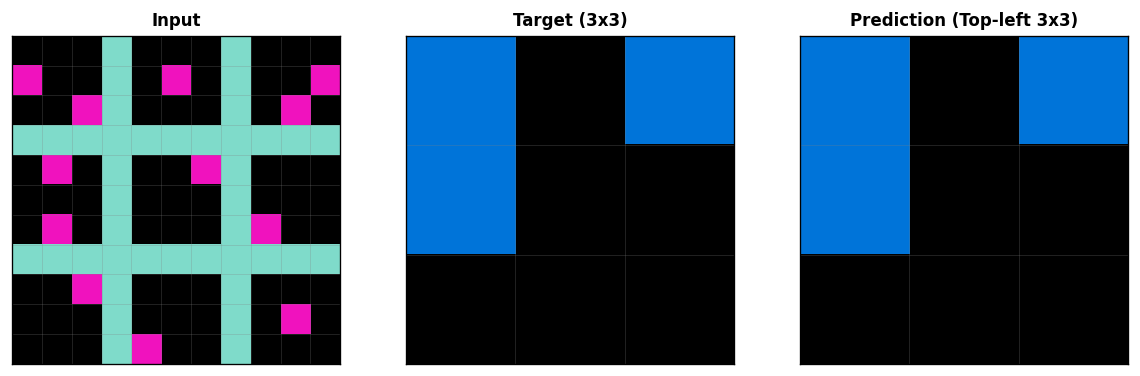

Results on ARC-AGI examples: 5 pass, 0 fail
Results on ARC-GEN examples: 262 pass, 0 fail

Your network IS READY for submission!

Performance stats (memory values reported here are approximate):
Name    Type    Forward_MACs    FPercent      Memory  MPercent      Params  PPercent    InShape     OutShape
------  ------  --------------  ----------  --------  ----------  --------  ----------  ----------  ----------
Conv_0  Conv    4,459           99.80%           560  93.96%            91  100.00%     1x10x30x30  1x1x7x7
Neg_2   Neg     9               0.20%             36  6.04%              0  0.00%       1x1x3x3     1x1x3x3
Total   _       4,468           100%             596  100%              91  100%        _           _

It appears to require 340 bytes + 97 params, yielding 18.920 points.

Next steps:
 * Click the link below to download task149.onnx onto your local machine.
 * Create a zip file containing that network along with all others.
 * Submit that zip file to the Kaggle comp

/kaggle/working/task149.onnx

In [6]:
def run_inference(grid, model_path):
    oh = np.zeros((1, 10, 30, 30), dtype=np.float32)
    for r in range(len(grid)):
        for c in range(len(grid[0])):
            oh[0, grid[r][c], r, c] = 1.0
    sess = ort.InferenceSession(model_path)
    out = sess.run(None, {'input': oh})[0]
    return (out[0] > 0.0).astype(int)

example_idx = 0
inp = task['train'][example_idx]['input']
target = task['train'][example_idx]['output']
pred_raw = run_inference(inp, "stride_tutorial.onnx")
pred = np.argmax(pred_raw, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_arc_grid(inp, axes[0], 'Input')
plot_arc_grid(target, axes[1], 'Target (3x3)')
plot_arc_grid(pred[:3, :3], axes[2], 'Prediction (Top-left 3x3)')
plt.show()

# Verify with official checker
import sys
sys.path.append("/kaggle/input/competitions/neurogolf-2026/neurogolf_utils")
from neurogolf_utils import *
passed = verify_network(model, 149, task)

# Summary
- **Stride** is used to skip pixels and reduce resolution.
- **Jump Frequency:** Stride 4 jumps every 4 pixels, perfect for 3x3 blocks with 1-pixel separators.
- **Formula:** Use the shape formula to ensure your stride lands exactly where you want it.
- **Assembly:** Using `Neg`, `Concat`, and `Pad` makes it easy to visualize how the model builds the 10-channel output from a single score map.

In [7]:
import shutil
import os
import zipfile

# --- CONFIGURATION ---
SOURCE_FOLDER = '/kaggle/input/datasets/massimilianoghiotto/neurogolf2026-6254/submission'
OUTPUT_ZIP = '/kaggle/working/submission.zip'

# Package the ZIP (Ensuring files are at the root)
with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SOURCE_FOLDER):
        for file in files:
            if file.endswith('.onnx'):
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, SOURCE_FOLDER))

### **This is the best that we are able to do for the moment, if anyone has any suggestion, please write it in the comments, we are happy to have some brainstorning between people.**